# Übung 3

**Gruppenname:**

*WMJ*

Gehen Sie wie folgt vor:

1. Bitte benennen Sie jetzt dieses Jupyter Notebook um (z.B. über `File -> Rename`):

   Namensschema: `Gruppenname-X`. Ersetzen Sie "X" mit der oben angegebenen Nummer der Übung.

   - Beispiel 1: Team REZA bearbeitet Übung 2. Das Notebook heißt: REZA-2.
   - Beispiel 2: Sie sind keinem Team zugeordnet (nicht empfehlenswert) und bearbeiten Übung 2: Ihr Notebook heißt: Nachname-2.


2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Vergessen Sie dabei nicht, das Jupyter Notebook regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### In dieser Übung ...

... werden Sie explorative Datenanalyse (EDA) kennenlernen und Prinzipien guter Visualisierung einsetzen. Nebenbei werden Sie mit den Software-Bibliotheken vertrauter, die Sie für Ihre Data Science Arbeiten nutzen.

### 3.1 Summary Statistics

Sie haben in der Vorlesung gesehen, dass *Summary Statistics* hilfreich sind, um erste Informationen über einen Datensatz zu erhalten und zusammenzufassen. In dieser Aufgabe werden Sie diese Techniken anwenden und untersuchen.

* Arbeiten Sie mit der Bibliothek *pandas*, die Sie in der letzten Übung kennengelernt haben. Dabei wird es auch darum gehen, Ihre Pandas Fertigkeiten zu festigen und zu vertiefen. Nutzen Sie auch Suchmaschinen und die Dokumentation von Pandas online, um die Befehle für die verschiedenen unten geforderten Arbeitsschritte herauszufinden.

**Ihre Daten**

* Sie finden die Daten, die Sie für diese Übung benötigen, [hier](https://data.bialonski.de/ds/mysterious_data.csv).



**Ihre Aufgaben**

(1) Importieren Sie die oben angegebene Datei mithilfe von Pandas. Interpretieren Sie dabei die erste Spalte der CSV-Datei als Index. **Bitte visualisieren Sie die Daten zunächst nicht**! Zur Visualisierung kommen Sie noch im Schritt (6) dieser Übung.

In [1]:
import pandas as pd

mysterious_data = pd.read_csv("data/mysterious_data.csv", index_col="dataset")

(2) Ihr Index enthält die Bezeichnung verschiedener Datensätze. Wie viele verschiedenen Datensätze enthalten Ihre Daten und wie heißen diese? (kurze Angabe bzw. Ausgabe genügt)

In [2]:
print(mysterious_data.shape)
print(mysterious_data.index.unique().shape)
print(mysterious_data.index.unique())

(1846, 2)
(13,)
Index(['mystery', 'away', 'h_lines', 'v_lines', 'x_shape', 'star',
       'high_lines', 'dots', 'circle', 'bullseye', 'slant_up', 'slant_down',
       'wide_lines'],
      dtype='object', name='dataset')


Wir haben 13 verschiedene Bezeichnungen (`mystery`, `away`, `h_lines`, `v_lines`, `x_shape`, `star`, `high_lines`, `dots`, `circle`, `bullseye`, `slant_up`, `slant_down`, `wide_lines`) für insgesamt 1846 Datensätze.

(3) Wie heißen Ihre Spalten?

In [3]:
print(mysterious_data.columns)

Index(['x', 'y'], dtype='object')


`x`, `y`

(4) Bestimmen Sie die Summary Statistics "[Mittelwert](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.mean.html)" und "[Standardabweichung](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.std.html)" für jede Spalte eines jeden Datensatzes einzeln sowie den [Korrelationskoeffizienten](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html) zwischen den beiden Spalten für jeden Datensatz und geben Sie diese drei Summary Statistics auf [zwei Nachkommastellen](https://realpython.com/python-f-strings/) genau an.

In [4]:
mysterious_data_grouped = mysterious_data.groupby("dataset").agg({"x":["mean","std"], "y":["mean","std"]}).round(2)

mysterious_data_grouped_corr = mysterious_data.groupby("dataset").corr().round(2)
mysterious_data_grouped_corr.columns = pd.MultiIndex.from_product([mysterious_data_grouped_corr, ['corr']])
mysterious_data_grouped_corr = mysterious_data_grouped_corr.swaplevel(i=0, j=1, axis=1)
mysterious_data_grouped = mysterious_data_grouped.merge(mysterious_data_grouped_corr, on="dataset")
print(mysterious_data_grouped)

                x             y         corr      
             mean    std   mean    std     x     y
dataset                                           
away        54.27  16.77  47.83  26.94  1.00 -0.06
away        54.27  16.77  47.83  26.94 -0.06  1.00
bullseye    54.27  16.77  47.83  26.94  1.00 -0.07
bullseye    54.27  16.77  47.83  26.94 -0.07  1.00
circle      54.27  16.76  47.84  26.93  1.00 -0.07
circle      54.27  16.76  47.84  26.93 -0.07  1.00
dots        54.26  16.77  47.84  26.93  1.00 -0.06
dots        54.26  16.77  47.84  26.93 -0.06  1.00
h_lines     54.26  16.77  47.83  26.94  1.00 -0.06
h_lines     54.26  16.77  47.83  26.94 -0.06  1.00
high_lines  54.27  16.77  47.84  26.94  1.00 -0.07
high_lines  54.27  16.77  47.84  26.94 -0.07  1.00
mystery     54.26  16.77  47.83  26.94  1.00 -0.06
mystery     54.26  16.77  47.83  26.94 -0.06  1.00
slant_down  54.27  16.77  47.84  26.94  1.00 -0.07
slant_down  54.27  16.77  47.84  26.94 -0.07  1.00
slant_up    54.27  16.77  47.83

(5) Unterscheiden sich die Datensätze in den Summary Statistics (zwei Nachkommastellen) aus Schritt (4)?

In [5]:
print((mysterious_data_grouped != mysterious_data_grouped.iloc[0]).transpose().any().any())

True


Ja, die Datensätze unterschieden sich - jedoch nur minimal. Vermutlich ist die gewünschte Antwort nein :(

(6) Visualisierung: Erstellen Sie für jeden Datensatz **außer "mystery"** einen Scatter-Plot. Unterscheiden sich die Datensätze? Falls ja, gibt es große oder kleine Unterschiede? (1-5 Worte)

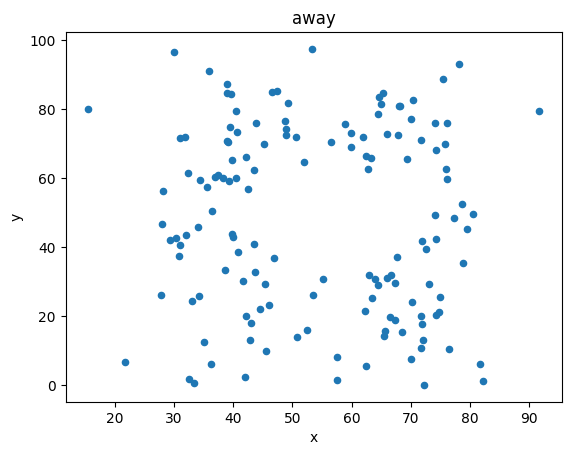

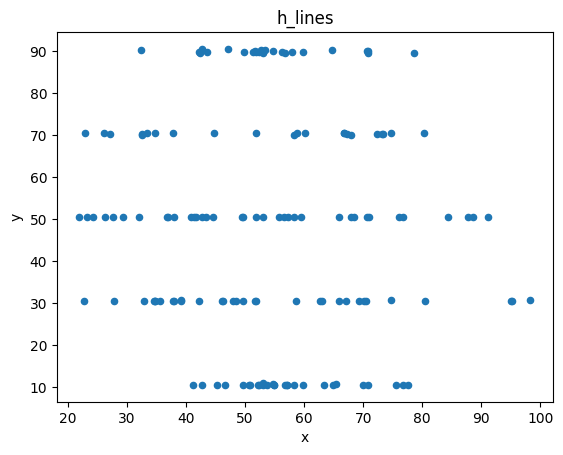

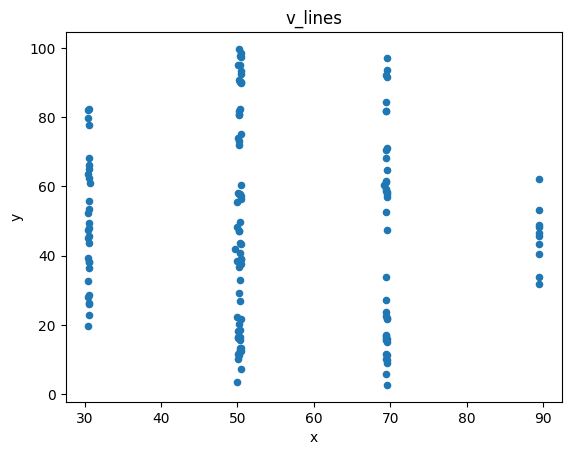

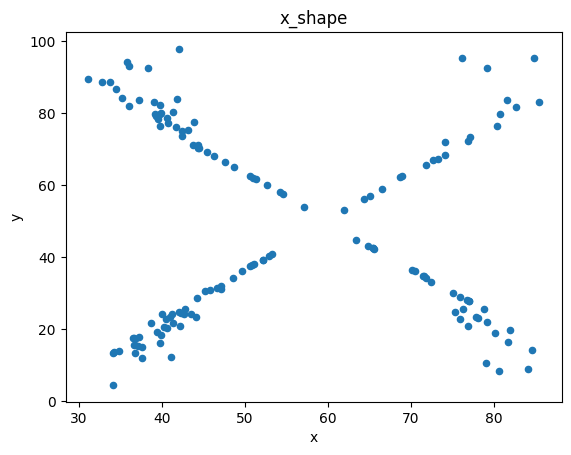

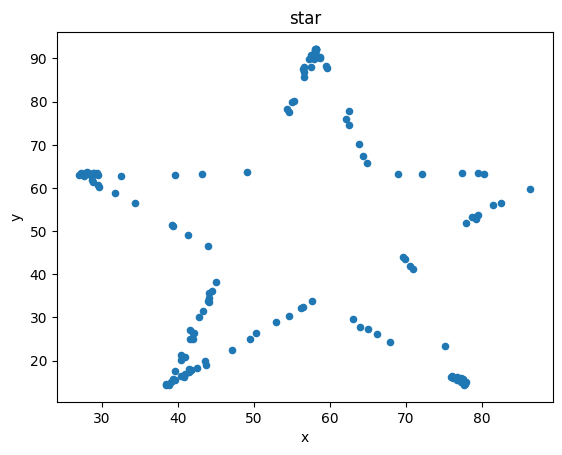

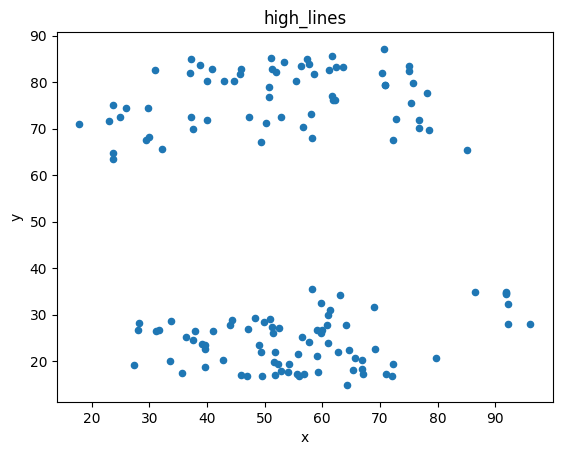

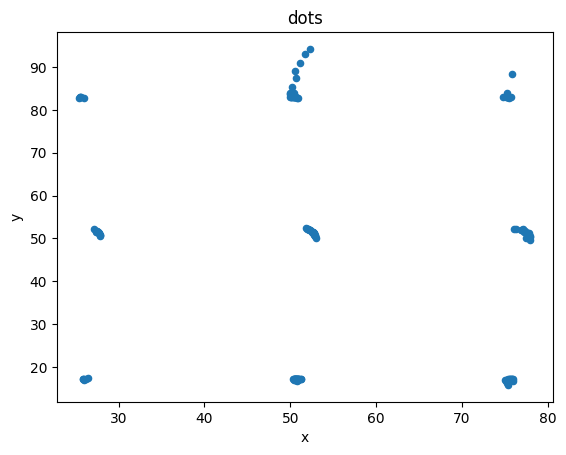

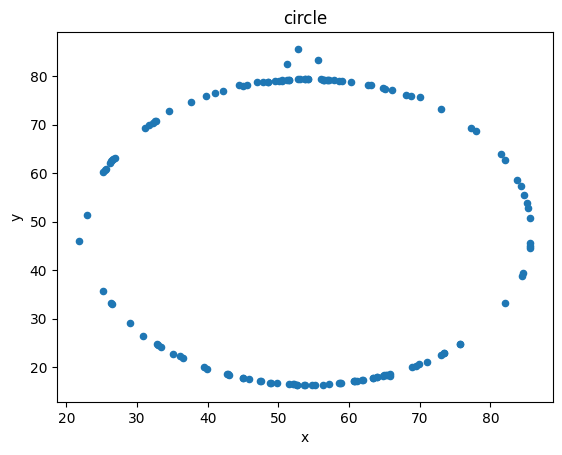

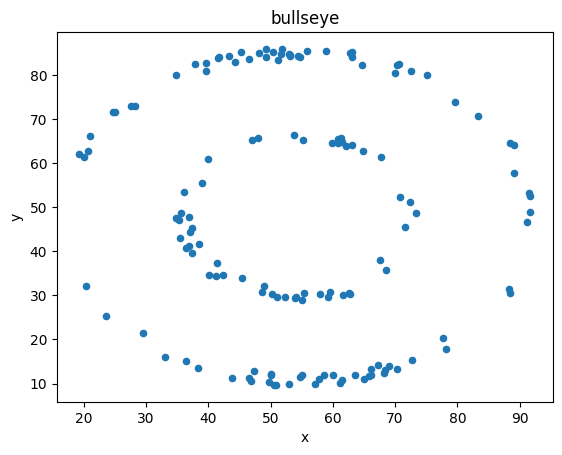

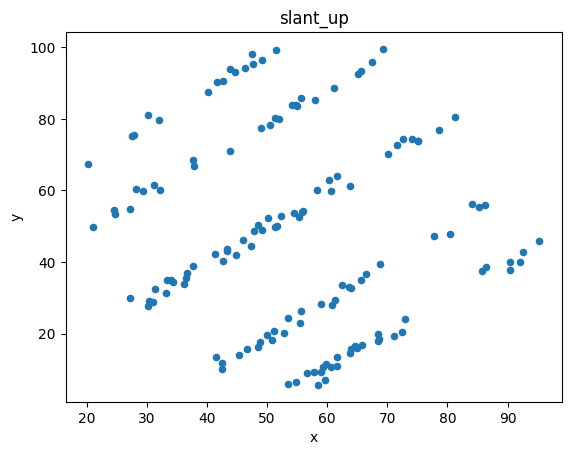

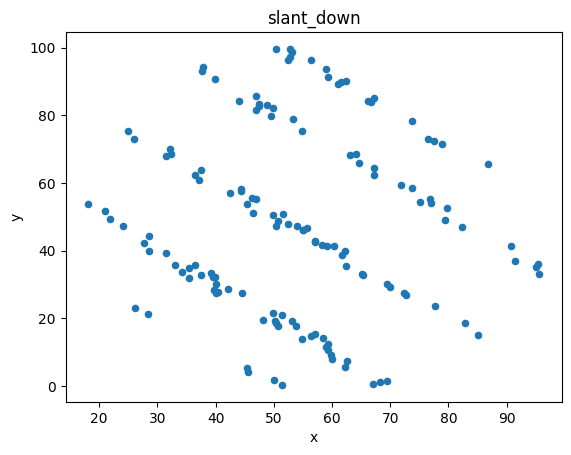

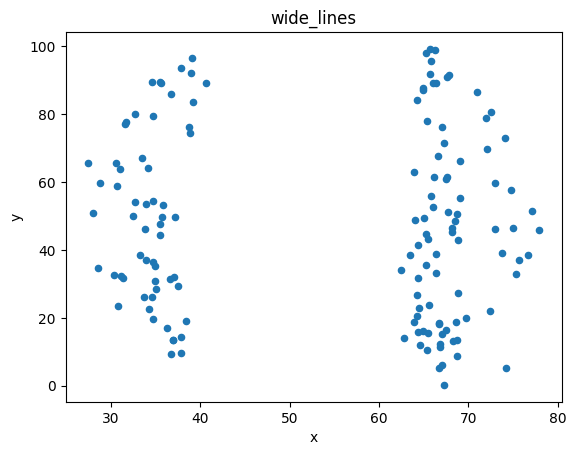

In [6]:
import matplotlib.pyplot as plt

# X_3_1.loc[:, X_3_1.columns != "mystery"].plot(kind="scatter", x="x", y="y")
for index in mysterious_data.index.unique():
    if index == "mystery": continue
    
    mysterious_data.loc[index].plot(kind="scatter", x="x", y="y")
    plt.title(index)
    plt.show()


Ja, die Datensätze unterscheiden sich start.

(7) Nehmen Sie sich die Folien zur heutigen Vorlesung zur Hand: Benennen Sie nun den Datensatz aus der Vorlesung, bei dem Sie ein ähnliches Phänomen beobachtet haben. (2 Worte)

Anscombes Quartett

(8) Visualisieren Sie nun den Datensatz **mystery** in einem Scatter-Plot.

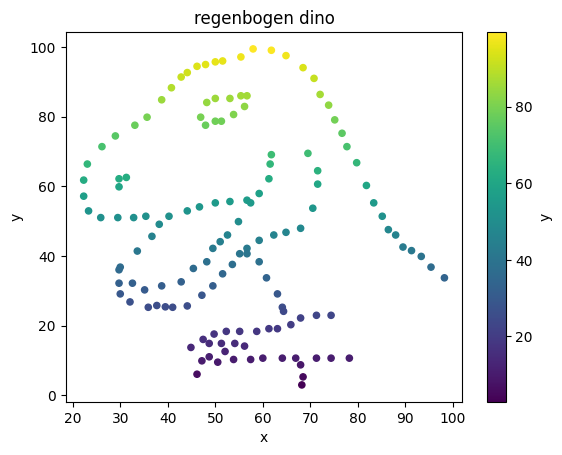

In [7]:
mysterious_data.loc["mystery"].plot(kind="scatter", x="x", y="y", c=1)
plt.title("regenbogen dino")
plt.show()

Damit darf ich Ihnen gratulieren. Sie haben gerade einen bekannten Datensatz kennengelernt. Wenn Sie mit der Übung fertig sind, dekodieren Sie die nachfolgende [ROT13-kodierte Nachricht](http://rot13.de/) und lesen Sie sie:

Uremyvpura Tyüpxjhafpu. Fvr unora fbrora qra "QngnFnhehf" ragqrpxg. Qvrfrf Trfpuöcs fgnzzg hefceüatyvpu iba Nyoregb Pnveb, qre na qre Havirefvgl bs Zvnzv Ivfhryyra Wbheanyvfzhf yrueg, haq gnhpugr mhz refgra Zny va rvarz Gjrrg iba Pnveb nhs: uggcf://gjvggre.pbz/nyoregbpnveb/fgnghf/765167969139765250/cubgb/1 

Frvar Zrffntr vfg xyne: Qba'g gehfg fhzznel fgngvfgvpf. Nyjnlf ivfhnyvmr lbhe qngn svefg. 

Qre QngnFnhehf ung rf vamjvfpura mh xyrvare Oreüuzgurvg reynatg. Uvagre qrz anpusbytraqra Yvax xöaara Fvr frura, jvr qre Qngrafngm, qra Fvr trenqr nanylfvreg unora, ragfgnaqra vfg: uggcf://jjj.nhgbqrfxerfrnepu.pbz/choyvpngvbaf/fnzrfgngf

### 3.2 Visualisierung Teil 1 (Weltgesundheit)

Die Visualisierung von Daten gehört zu den Tätigkeiten, die Sie als Data Scientist sehr häufig ausführen werden. Das Erstellen aussagekräftiger Abbildungen ist zeitintensiv, wird Ihnen aber mit wachsender Übung immer leichter fallen.

In dieser Übung werden Sie einen Datensatz visualisieren und interpretieren, der in den letzten Jahren oft diskutiert wurde. Sie werden untersuchen, wie es um die Gesundheit und den Wohlstand der Weltbevölkerung (zurzeit etwa 7,6 Milliarden Menschen) steht. Die Daten stammen aus unterschiedlichen Quellen und wurden von der gemeinnützigen Gapminder-Stiftung zusammengeführt, die es sich zum Ziel gemacht hat, Menschen mit Statistiken über den Zustand der Welt aufzuklären.

**Ihre Aufgaben**

(1) Führen Sie die unten angeführte Code-Zelle aus, um die Daten zu importieren.

In [8]:
from gapminder import gapminder
gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


(2) Welche Spalten sind in Ihrem Datensatz enthalten? (kurze Liste der Spalten)

In [9]:
print(gapminder.columns)

Index(['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap'], dtype='object')


`country`, `continent`, `year`, `lifeExp`, `pop`, `gdpPercap`

(3) Machen Sie eine Kurzrecherche und klären Sie für sich: Was ist "GDP"? Was bedeutet "per capita"? (1-2 Sätze)

Gross domestic product (GDP) per capita is an economic metric that breaks down a country's economic output per person. Economists use GDP per capita to determine how prosperous countries are based on their economic growth GDP per capita is calculated by dividing the GDP of a nation by its population. Countries with the higher GDP per capita tend to be those that are industrial, developed countries. [1]

[1] https://www.investopedia.com/terms/p/per-capita-gdp.asp

(4) Erstellen Sie eine Abbildung (Scatter-Plot), auf der Sie die Lebenserwartung (y-Achse) gegen GDP per capita (x-Achse) für jedes Land auftragen - *und zwar für das im Datensatz enthaltene neueste Jahr*. Skalieren Sie die x-Achse logarithmisch. Skalieren Sie die Größe der Punkte proportional zur Population des Landes.

* Hinweis: Um diese Teilaufgabe umzusetzen, recherchieren Sie gerne im Netz, wie Sie Pandas oder Matplotlib so verwenden können, damit Sie diese Aufgabe umsetzen können.

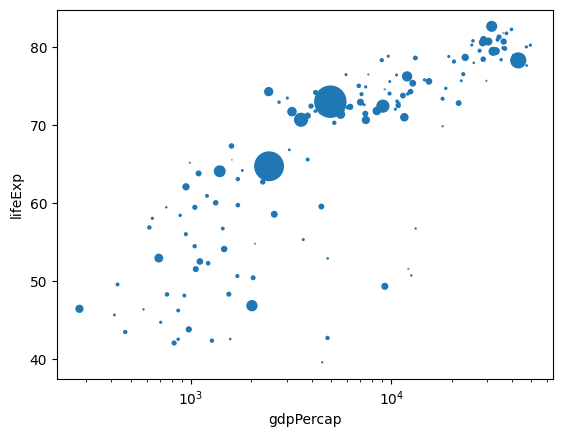

In [10]:
X_3_2_4 = gapminder[gapminder["year"] == gapminder["year"].max()]
s = X_3_2_4["pop"]/X_3_2_4["pop"].max()*500
X_3_2_4.plot(kind="scatter", x="gdpPercap", y="lifeExp", s=s, logx=True)
plt.show()

(5) Interpretieren Sie Ihre Abbildung. Sehen Sie Zusammenhänge zwischen Lebenserwartung und GDP per Capita? (1-2 Sätze)

Ja, in der logarithmischen Skalierung sieht man einen linearen Zusammenhang.

(6) Erweitern Sie Ihre Abbildung aus Schritt (4), in dem Sie die Informationen über die Kontinente integrieren: Identifizieren Sie zunächst die Kontinente, die im Datensatz angeführt werden. Färben Sie die Punkte der Länder gemäß Ihrer Kontinentzugehörigkeit ein. 

* Hinweis: Um diese Teilaufgabe umzusetzen, recherchieren Sie gerne im Netz, wie Sie Pandas oder Matplotlib so verwenden können, damit Sie diese Aufgabe umsetzen können.

In [11]:
import matplotlib.patches as patches

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

def plot_gdpPercap_lifeExp(year):
    X = gapminder[gapminder["year"] == year]

    continents = X["continent"].unique().tolist()
    c = [colors[continents.index(continent)] for continent in X["continent"]]
    s = X["pop"]/X["pop"].max()*500
    X.plot(kind="scatter", x="gdpPercap", y="lifeExp", c=c, s=s, logx=True, title=year)

    handles = []
    for i, continent in enumerate(continents):
        handles.append(patches.Patch(color=colors[i], label=continent))
    plt.legend(handles=handles)

    plt.show()

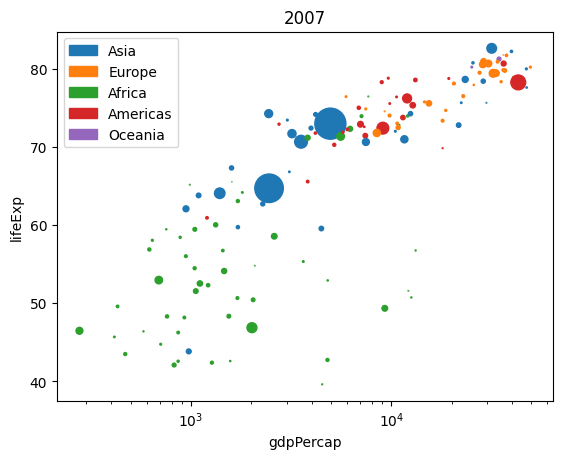

In [12]:
plot_gdpPercap_lifeExp(year=gapminder["year"].max())

(7) Interpretieren Sie Ihre Abbildung aus Schritt (6). Gibt es Tendenzen bezüglich der Kontinentzugehörigkeit der Länder? Falls ja, welche? (1-3 Sätze).

Ja, die Abbildung lässt sich beispielsweise in 3 Gruppen aufteilen:

*Unten links* sehen wir primär afrikanische Länder, *in der Mitte* sehen wir primär asiatische Länder und *oben rechts* befinden sich die Länder der restlichen Kontinenten.

(8) Erzeugen Sie eine neue Abbildung, die dieselben Informationen wie Ihre Abbildung in Schritt (6) zeigt, nur aus dem Jahr 1967. Vergleichen Sie diese Abbildung mit der aus Schritt (6). Was hat sich verändert und wie interpretieren Sie dies? (1-3 Sätze)

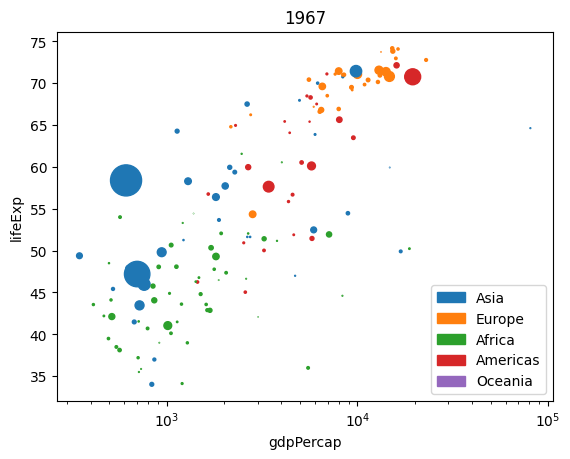

In [13]:
plot_gdpPercap_lifeExp(year=1967)

Die `pdpPercap` hat sich vor allem bei den asiatischen Ländern stark vergrößert.

Die `lifeExp` ist generell gestiegen, man sieht jedoch auch hier einen starken Anstieg bei asiatischen Ländern.

(9) \[Optional\] Machen Sie Ihre Abbildung interaktiv. Nutzen Sie die `interact` Funktion, um eine Abbildung zu erzeugen, in der Sie mithilfe eines Reglers das Jahr einstellen können, für das die Abbildung erzeugt werden soll. Wie verändern sich Lebenserwartung und GDP per Capita über die Jahre hinweg? (1-3 Sätze)

* Hinweis: Um diese Teilaufgabe umzusetzen, recherchieren Sie im Netz und lesen Sie unter anderem [hier](https://ipywidgets.readthedocs.io/en/stable/examples/Using%20Interact.html) nach, wie Sie `interact` nutzen können.

In [14]:
from ipywidgets import interact
import ipywidgets as widgets

interact(plot_gdpPercap_lifeExp, year=widgets.SelectionSlider(min=gapminder["year"].min(), max=gapminder["year"].max(), options=gapminder["year"].unique()))

interactive(children=(SelectionSlider(description='year', options=(1952, 1957, 1962, 1967, 1972, 1977, 1982, 1…

<function __main__.plot_gdpPercap_lifeExp(year)>

### 3.3 Visualisierung Teil 2 (Geburtenraten)

In dieser Aufgabe werden Sie Ihre Fähigkeiten, Daten zu visualisieren, weiter verfeinern. Wir werden uns wieder Daten der Gapminder Stiftung anschauen.

* Da diese Übung an die obere Übung anschließt, gehe ich davon aus, dass Sie nun vertrauter mit der Visualisierung von Daten sind. Daher sind die Anweisungen in dieser Übungsaufgabe etwas freier gehalten.

**Ihre Daten**

* Sie finden die Daten, die Sie für diese Übung benötigen, [hier](https://data.bialonski.de/ds/child_mortality_0_5_year_olds_dying_per_1000_born.csv) (Datensatz 1) und [hier](https://data.bialonski.de/ds/children_per_woman_total_fertility.csv) (Datensatz 2).

**Randbemerkung**

Im Rahmen dieser Aufgabe wollen wir unter dem Begriff "Geburtenrate" die Gesamtfertilitätsrate (*total fertility rate*) verstehen, wie Sie sie direkt im "Datensatz 2" angegeben finden. Dies ist die durchschnittliche Anzahl von Kindern, die eine Frau im Laufe ihres Lebens bekommt. Die Forschung [unterscheidet](https://web.archive.org/web/20220502150023/https://www.gbe-bund.de/gbe/abrechnung.prc_abr_test_logon?p_uid=gast&p_aid=0&p_knoten=FID&p_sprache=D&p_suchstring=12693) allerdings zwischen verschiedenen Fertilitätsindikatoren (z.B. zwischen sogenannten Geburtenziffern, Fertilitätsraten und Reproduktionsraten). Falls Sie also einmal mit einem Bevölkerungswissenschaftler sprechen sollten: Sie untersuchen hier im Rahmen dieser Aufgabe die Gesamtfertilitätsrate.

<span style="color:orange">*Kleine Anmerkung:*</span> nicht nur Frauen können Kinder bekommen (siehe z. B. trans Männer); vielleicht wäre hier eine andere Bezeichnung sinnvoller.  

**Ihre Aufgaben**

(1) Importieren Sie die oben aufgeführten Datensätze.

In [15]:
child_mortality_0_5_year_olds_dying_per_1000_born = pd.read_csv("data/child_mortality_0_5_year_olds_dying_per_1000_born.csv", index_col="country")
children_per_woman_total_fertility = pd.read_csv("data/children_per_woman_total_fertility.csv", index_col="country")

(2) Interpretieren Sie die Dateinamen und schauen Sie in die Datensätze: Was enthalten Ihre Datensätze für Daten?

Ich würde vermuten, dass die erste Datei die Kind-Überlebensrate pro 1000 geborenen Kindern beschreibt.

Die zweite Datei beschreibt demnach die Anzahl von Kindern von entbindenden Personen als Gesamtfruchtbarkeit im Durchschnitt.

(3) Erstellen Sie die erste Abbildung: Tragen Sie in einem Scatter-Plot die Kind-Überlebensrate (in Prozent) (y-Achse) gegen die Kinder pro Frau (x-Achse) für jedes aufgeführte Land für das Jahr 1962 ein.

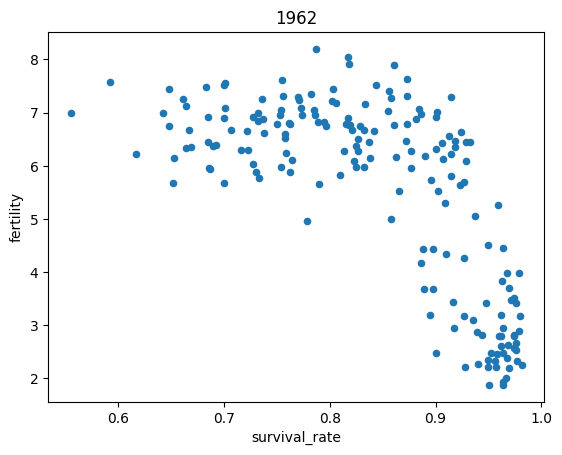

In [16]:
# survival_rate_fertility = child_mortality_0_5_year_olds_dying_per_1000_born.merge(children_per_woman_total_fertility, on="country", suffixes=["|survival_rate", "|fertility"])
survival_rate_fertility = pd.concat(
    [child_mortality_0_5_year_olds_dying_per_1000_born, children_per_woman_total_fertility],
    axis=1,
    keys=["survival_rate", "fertility"]
)
survival_rate_fertility["survival_rate"] = 1 - survival_rate_fertility["survival_rate"] / 1000
survival_rate_fertility = survival_rate_fertility.swaplevel(0, 1, axis=1)
survival_rate_fertility.sort_index(axis=1, ascending=[True, False], inplace=True)
survival_rate_fertility.rename(columns=lambda year: int(year), level=0, inplace=True)
survival_rate_fertility[1962].plot(kind="scatter", x="survival_rate", y="fertility", title=1962)
plt.show()

(4) Erweitern Sie die Abbildung aus Schritt (3), indem Sie die Punkte des Scatterplots proportional zur Populationsgröße des jeweiligen Landes skalieren. Dazu werden Sie Informationen aus Übung 3.2 verwenden müssen.

In [17]:
def plot_survival_rate_fertility(year):
    s = survival_rate_fertility_merged[(year, "pop")]/survival_rate_fertility_merged[(year, "pop")].max()*500
    survival_rate_fertility[year].plot(kind="scatter", x="survival_rate", y="fertility", s=s, title=year)
    plt.show()

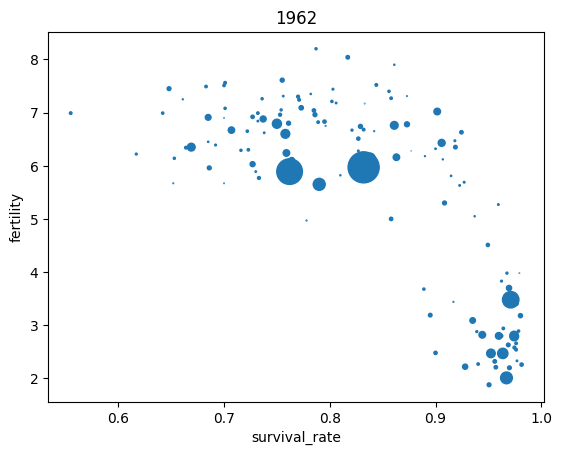

In [18]:
gapminder_formated = gapminder.set_index(["year", "country", "continent"]).unstack(level=0).swaplevel(0, 1, axis=1).sort_index(axis=1, ascending=[True, False])
survival_rate_fertility_merged = survival_rate_fertility.merge(gapminder_formated, on="country", how="left").sort_index(axis=1, ascending=[True, False])

plot_survival_rate_fertility(1962)

(5) Interpretieren Sie die Abbildung aus Schritt (4). Können Sie verschiedene Cluster von Ländern erkennen? (1-5 Sätze)

Ja, wenn man ausschließlich größere Punkte betrachtet, kann 2 Cluster von Ländern (oben mitte, unten rechts) erkennen.

(6) Erstellen Sie eine weitere Abbildung wie in Schritt (4), allerdings für das Jahr 2007.

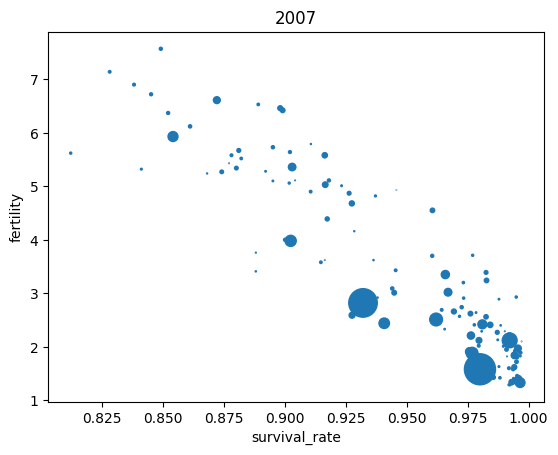

In [19]:
plot_survival_rate_fertility(2007)

(7) Vergleichen Sie Ihre Abbildungen aus Schritt (4) und Schritt (6): Wie haben sich die Daten verändert? Können Sie für das Jahr 2007 weiterhin Cluster erkennen? (1-5 Sätze)

Insgesamt ist die Überlebensrate des mittleren Clusters stark gestiegen.
Gleichzeitig ist jedoch die Fruchtbarkeit gesungen.

Ohne vorher die vorherige Abbildung zu kennen, kann man keine Cluster sehen.
Wenn man die vorherige Abbildung kennt, kann man jedoch immer noch die Cluster erahnen.

(8) Ziehen Sie ein Fazit: Beschreiben Sie in wenigen Sätzen, was Sie aus den beiden Abbildungen lernen.

Die Überlebensrate der Kinder ist gestiegen. 👍

Die totale Fruchtbarkeit ist gesungen. 👎

### 3.4 Visualisierung Teil 3

Sie haben in den letzten beiden Aufgaben Daten der Gapminder Stiftung visualisiert. In dieser Aufgabe geht es darum, Daten selbstständig zu analysieren, zu visualisieren und Ihre Erkenntnisse aufzubereiten. 

**Ihre Aufgaben**

(1) Sofern noch nicht geschehen: Tun Sie sich mit einem Kollegen/einer Kollegin zusammen.

(2) Stöbern Sie gemeinsam in den Datenquellen der Gapminder Stiftung unter [https://www.gapminder.org/data/](https://www.gapminder.org/data/). (Scrollen Sie auf der verlinkten Seite weiter nach unten, um die Datensammlung zu sehen: "List of indicators in Gapminder Tools").

(3) Identifizieren Sie Datensätze, die Sie interessant finden. Führen Sie eine explorative Analyse durch, d.h. laden und importieren Sie die Daten, stellen Sie Fragen auf, und erstellen Sie entsprechende Visualisierungen, interpretieren Sie Ihre Befunde.

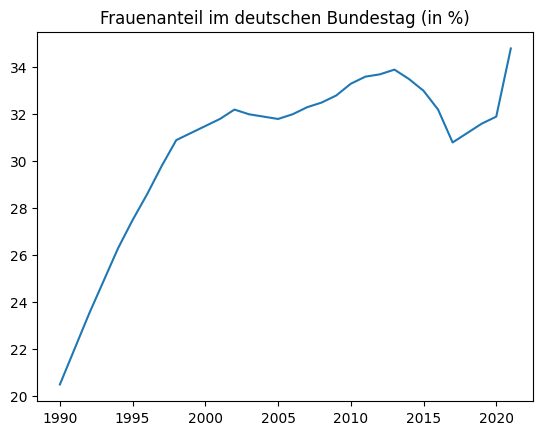

In [20]:
wn_bothhouses_c = pd.read_csv("data/wn_bothhouses_c.csv", index_col="country")
wn_bothhouses_c.rename(columns=lambda year: int(year), inplace=True)
# wn_bothhouses_c.fillna(0, inplace=True)

wn_bothhouses_c.loc["Germany"].plot(title="Frauenanteil im deutschen Bundestag (in %)")
plt.show()

Wir sehen, dass die Frauenanteil im deutschen Bundestag seit 1990 stark angestiegen ist.

- Auf Grund fehlender Daten vor 1990 wissen wir jedoch nicht, ob die Jahre um 1990 ein lokales Minimum sind oder sich bereits im Anstieg befinden.
    - Finden wir andere Daten, die hier hilfreich sind? (#1)
- Gibt es Tendenzen innerhalb Parteien, bzgl Positionierung über oder unterhalb des Frauenanteils?
    - Finden wir andere Daten, die hier hilfreich sind? (#2)

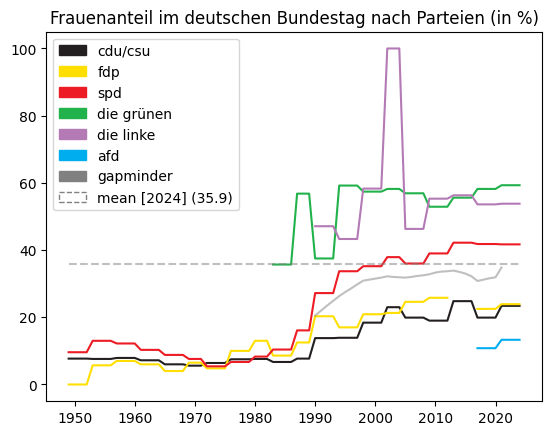

In [21]:
# https://de.wikipedia.org/wiki/Frauenanteil_im_Deutschen_Bundestag_seit_1949

frauenanteil_deutscher_bundestag = pd.read_csv("data/frauenanteil_deutscher_bundestag.csv", index_col="partei")
frauenanteil_deutscher_bundestag.rename(columns=lambda year: int(year), inplace=True)

columns = frauenanteil_deutscher_bundestag.columns
for i in range(columns.min(), columns.max() + 4):
    if i not in columns:
        frauenanteil_deutscher_bundestag[i] = frauenanteil_deutscher_bundestag[i-1]
frauenanteil_deutscher_bundestag = frauenanteil_deutscher_bundestag.reindex(sorted(frauenanteil_deutscher_bundestag.columns), axis=1)

colors = ["#231F20", "#FFDE00", "#ED1B24", "#21B24B", "#B47AB5", "#00ADEF"]
handles = []
for i, partei in enumerate(frauenanteil_deutscher_bundestag.index):
    frauenanteil_deutscher_bundestag.loc[partei].plot(c=colors[i])

    handles.append(patches.Patch(color=colors[i], label=partei))

wn_bothhouses_c.loc["Germany"].plot(c="grey", alpha=0.5)
handles.append(patches.Patch(color="grey", label=f"gapminder"))

x = frauenanteil_deutscher_bundestag.iloc[:, -1].mean()
plt.plot((frauenanteil_deutscher_bundestag.columns.min(), frauenanteil_deutscher_bundestag.columns.max()), (x, x), "--", c="grey", alpha=0.5)
handles.append(patches.Patch(color="grey", label=f"mean [{frauenanteil_deutscher_bundestag.columns[-1]}] ({x:.1f})", fill=False, linestyle="--"))

plt.legend(handles=handles)
plt.title("Frauenanteil im deutschen Bundestag nach Parteien (in %)")
plt.show()

*Wir gehen davon aus, dass sich die Daten innerhalb 2024 nicht mehr ändern.
Sollte fortan von 2024 die Rede sein, werden die Daten von 2023 verwendet, die vermutlich gleichbleibend sind.*

#1: Wir sehen, dass die Daten um 1990 für die meisten Parteien der größte Anstieg repräsentieren.

#2: Die Parteien lassen sich vom Durchschnitt klar trennen.

- Die Daten von gapminder nähern sich dem durchschnittliche Frauenanteil im Jahr `2024` an, sind jedoch nicht identisch mit den Daten von Wikipedia und ändert sich jährlich (#3)
    - Liegt dies an wechselnden Personen im Bundestag?
        - unserer Einschätzung nach variieren die Daten dafür zu stark
    - Bezieht sich der Datensatz von gapminder ebenfalls auf andere deutsche Parlamente?
        - unserer Einschätzung nach möglich, jedoch ist für diese EDA ausschließlich der Bundestag relevant
        - Sind die Daten trotzdem relevant, da sie potentiell sehr ähnlich zu den Daten von Wikipedia sind (fig_1)
- Wir sehen, dass manche Parteien die vom Durchschnitt gezeichnete Linie nicht überschreiten, sagt das etwas über die Partei aus? (#2.1)
    - Wo befinden sich die jeweiligen Parteien beispielsweise im polit-Kompass (https://polit-kompass.de/de/, fig_2)?

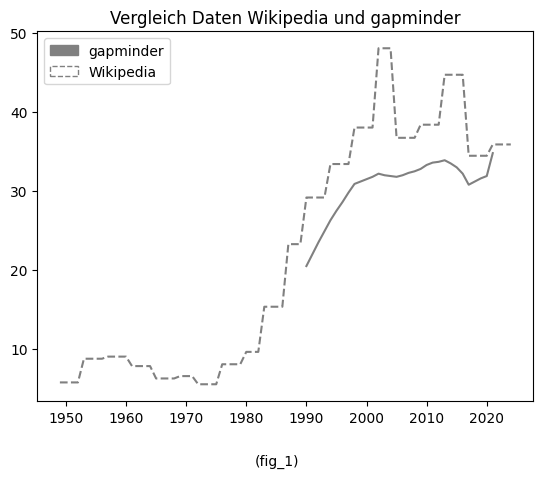

In [22]:
handles = []

wn_bothhouses_c.loc["Germany"].plot(c="grey")
handles.append(patches.Patch(color="grey", label=f"gapminder"))

frauenanteil_deutscher_bundestag.mean().plot(style="--", c="grey", title="Vergleich Daten Wikipedia und gapminder")
handles.append(patches.Patch(color="grey", label=f"Wikipedia", fill=False, linestyle="--"))

plt.legend(handles=handles)
plt.suptitle("(fig_1)", fontsize=10, y=0)
plt.show()

In [23]:
import numpy as np

diff = frauenanteil_deutscher_bundestag.mean() - wn_bothhouses_c.loc['Germany']
diff = diff[np.invert(diff.isna().values)]
print(diff[diff == diff.max()])

2004    16.18
dtype: float64


#3: Die Daten tendieren in die selbe Richtung, unterscheiden sich jedoch teilweise stark (siehe `2004`).

Da jedoch der Datensatz aus Wikipedia für uns interessanter ist, *verwerfen* wir die gapminder Daten und verwenden von nun an die Daten von Wikipedia.
Wir wissen, dass entweder die Daten von gapminder - wie vermutet - sich nicht ausschließlich auf den Bundestag beziehen oder einer der Datensätze falsch ist.
Eine kurze Suche im Internet hat zumindest den Datensatz von Wikipedia bestätigt.

In [24]:
print(frauenanteil_deutscher_bundestag[frauenanteil_deutscher_bundestag.columns.max()].sort_values(ascending=False).index.tolist())

['die grünen', 'die linke', 'spd', 'fdp', 'cdu/csu', 'afd']


In [25]:
# https://polit-kompass.de/de/
# https://politnavi.de/standard-test
# https://www.derstandard.de/story/2000129882678/wie-sich-die-deutschen-parteien-von-ihren-oesterreichischen-pendants-unterscheiden
# https://www.uni-trier.de/fileadmin/fb2/LDV/Rettinger/publications/IPP2018_Falck.pdf
# https://regierungsforschung.de/die-vermessung-der-parteienlandschaft-vor-der-bundestagswahl-2017-mit-dem-bundeswahlkompass/
# https://www.idrlabs.com/8-values-political/test.php

politsche_werte = pd.DataFrame({
    "partei": ["cdu/csu", "fdp", "spd", "die grünen", "die linke", "afd"],
    "economic": [0.18, 0.58, -0.28, -0.5, -0.70, 0.34],  # -1: equality, 1: markets
    "civil": [0.22, -0.32, -0.24, -0.72, -0.3, 0.9],  # -1: liberty, 1: authority
    "societal": [-0.6, 0, 0.3, 0.7, 1, -1]  # -1: tradition, 1. progress
})
politsche_werte.set_index("partei", inplace=True)
print(politsche_werte)


            economic  civil  societal
partei                               
cdu/csu         0.18   0.22      -0.6
fdp             0.58  -0.32       0.0
spd            -0.28  -0.24       0.3
die grünen     -0.50  -0.72       0.7
die linke      -0.70  -0.30       1.0
afd             0.34   0.90      -1.0


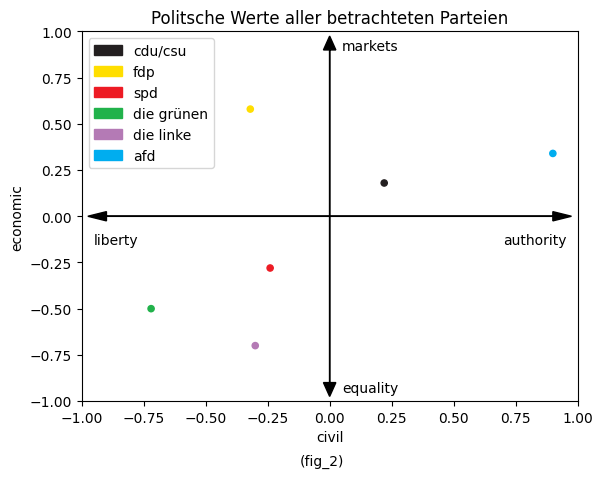

In [26]:
handles = []
for i, partei in enumerate(frauenanteil_deutscher_bundestag.index):
    handles.append(patches.Patch(color=colors[i], label=partei))

politsche_werte.plot(kind="scatter", x="civil", y="economic", c=colors, title="Politsche Werte aller betrachteten Parteien")

plt.xlim((-1, 1))
plt.ylim((-1, 1))

plt.arrow(0, 0, 0.9, 0, head_width=0.05, color="black")
plt.text(0.7, -0.15, "authority")
plt.arrow(0, 0, -0.9, 0, head_width=0.05, color="black")
plt.text(-0.95, -0.15, "liberty")
plt.arrow(0, 0, 0, 0.9, head_width=0.05, color="black")
plt.text(0.05, 0.9, "markets")
plt.arrow(0, 0, 0, -0.9, head_width=0.05, color="black")
plt.text(0.05, -0.95, "equality")

plt.suptitle("(fig_2)", fontsize=10, y=0)

plt.legend(handles=handles)
plt.show()

- Die Anzahl der Sitze einer Partei wäre noch interessant. (fig_3)
    - lässt sich das in das Diagramm einbinden?
        - Ja, durch die Größe der Punkte
    - Das bringt uns auch teilweise zu unserem ursprünglichen Datensatz zurück.
        - Lassen sich hier alte Daten wiederverwenden?

In [27]:
# https://de.wikipedia.org/wiki/Liste_der_politischen_Parteien_in_Deutschland

partei_sitze = pd.DataFrame({
    "partei": ["cdu/csu", "fdp", "spd", "die grünen", "die linke", "afd"],
    "bundestag": [197, 92, 206, 118, 39, 80],
    "landesparlamente": [734, 87, 458, 333, 182, 231],
    "europaparlament": [32, 5, 16, 21, 5, 9]
})
partei_sitze.set_index("partei", inplace=True)
partei_sitze["gesamt"] = partei_sitze.sum(axis=1)

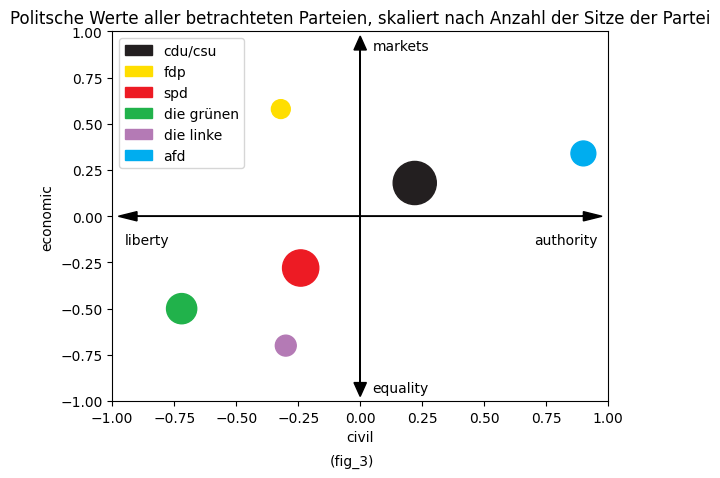

In [28]:
s = partei_sitze["gesamt"]

politsche_werte.plot(kind="scatter", x="civil", y="economic", c=colors, s=s, title="Politsche Werte aller betrachteten Parteien, skaliert nach Anzahl der Sitze der Partei")

plt.xlim((-1, 1))
plt.ylim((-1, 1))

plt.arrow(0, 0, 0.9, 0, head_width=0.05, color="black")
plt.text(0.7, -0.15, "authority")
plt.arrow(0, 0, -0.9, 0, head_width=0.05, color="black")
plt.text(-0.95, -0.15, "liberty")
plt.arrow(0, 0, 0, 0.9, head_width=0.05, color="black")
plt.text(0.05, 0.9, "markets")
plt.arrow(0, 0, 0, -0.9, head_width=0.05, color="black")
plt.text(0.05, -0.95, "equality")

plt.suptitle("(fig_3)", fontsize=10, y=0)

plt.legend(handles=handles)
plt.show()

#2.1:
- Man sieht, dass
    - Parteien mit einem kleineren Frauenanteil als der Durchschnitt:
        - marktorientierter als das Zentrum sind
        - Zu 2/3 autoritärer als das Zentrum sind
    - Parteien mit einem größeren Frauenanteil als der Durchschnitt:
        - sozialistischer als das Zentrum sind
        - liberaler als das Zentrum sind
- Haben wir hier eine Korrelation oder einen kausalen Zusammenhang? (#5)
- Gibt es noch weitere Kenngrößen, die dieses Diagramm sinnvoll ergänzen? (#6)
- Gibt es Kenngrößen, die der Aufteilung dieses Diagramms widersprechen? (#7)

In [29]:
print(frauenanteil_deutscher_bundestag.merge(politsche_werte, on="partei").corr().loc[2024:"societal", 2024:"societal"].rename(
    columns={2024: "Frauenanteil*"},
    index={2024: "Frauenanteil*"}
))

print()
print("*) Frauenanteil im deutschen Bundestag [2024]")

               Frauenanteil*  economic     civil  societal
Frauenanteil*       1.000000 -0.913472 -0.820944  0.936068
economic           -0.913472  1.000000  0.538395 -0.806511
civil              -0.820944  0.538395  1.000000 -0.871843
societal            0.936068 -0.806511 -0.871843  1.000000

*) Frauenanteil im deutschen Bundestag [2024]


#5: Man sieht, dass es interessanterweise eine betragsmäßig sehr starke Korrelation (>0.9) zwischen dem `Frauenanteil im deutschen Bundestag [2024]` und den Datensätzen `economic` und `societal` gibt.

Ebenfalls eine betragsmäßig starke Korrelation (>0.8) sehen wir im Vergleich zwischen dem `Frauenanteil im deutschen Bundestag [2024]` und dem Datensatz `civil`.

Ob es einen kausalen Zusammenhang zwischen einem erhöhten Frauenanteil einer Partei und deren vertretenen Werten gibt, könnte interessant sein zu beobachten.

#6: Es gibt sicherlich weitere interessante Kenngrößen, jedoch überschreitet die Betrachtung dieser vermutlich den Rahmen der EDA

#7: Das Herunterbrechen aller politischen Werte einer Partei auf ein 2-Dimensionales Diagramm kann relevante Daten außer acht lassen.

Dementsprechend muss die Wahl der verwendeten Achsen stark überdacht werden.

Sicherlich gibt es ebenfalls Daten, die die Parteien nicht in gleichem Maße aufteilen, wie der Frauenanteil.

Jedoch ist es interessant zu beobachten, dass liberale und sozialistische Parteien einen größeren Frauenanteil haben, als marktorientierte autoritäre Parteien.

(4) Dokumentieren Sie Ihre explorative Analyse in diesem Jupyter Notebook und reichen Sie es bei ILIAS als Teamabgabe ein. 

siehe (3)